In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score


# Correlation


In [2]:
df = pd.read_csv("../supp_fig1/sample_metadata.csv")
df = df[df['Experiment'].isin(['igvf_003', 'igvf_004', 
                              'igvf_005', 'igvf_007', 
                              'igvf_008', 'igvf_008b', 
                              'igvf_009', 'igvf_010', 
                              'igvf_011', 'igvf_012'])]

df = df[['Mouse_Tissue_ID', 'Genotype', 'Tissue', 'Sex', 'Body_weight_g', 'Tissue_weight_mg']]


df = df.drop_duplicates()

df['Tissue'].replace('HypothalamusPituitary', 'Diencephalon/Pituitary', inplace=True)
df['Tissue'].replace('CortexHippocampus', 'Cortex/Hippocampus', inplace=True)
df['Tissue'].replace('Adrenal', 'Adrenal gland', inplace=True)
df['Tissue'].replace('GonadsMale', 'Testes/Epididymis', inplace=True)
df['Tissue'].replace('GonadsFemale', 'Ovary/Oviduct', inplace=True)
df['Body_weight_g'] = pd.to_numeric(df['Body_weight_g'])
df['Tissue_weight_mg'] = pd.to_numeric(df['Tissue_weight_mg'])

# Drop rows with NaN values
df.dropna(subset=['Body_weight_g', 'Tissue_weight_mg'], inplace=True)

df['Mouse_ID'] = df['Mouse_Tissue_ID'].str.split('_').str[0]



/tmp/ipykernel_1903025/2243616409.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Tissue'].replace('HypothalamusPituitary', 'Diencephalon/Pituitary', inplace=True)
/tmp/ipykernel_1903025/2243616409.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doin

Cortex/Hippocampus


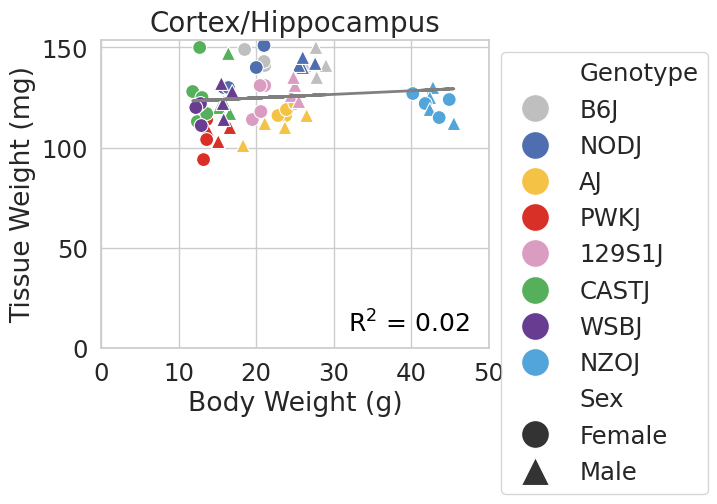

Heart


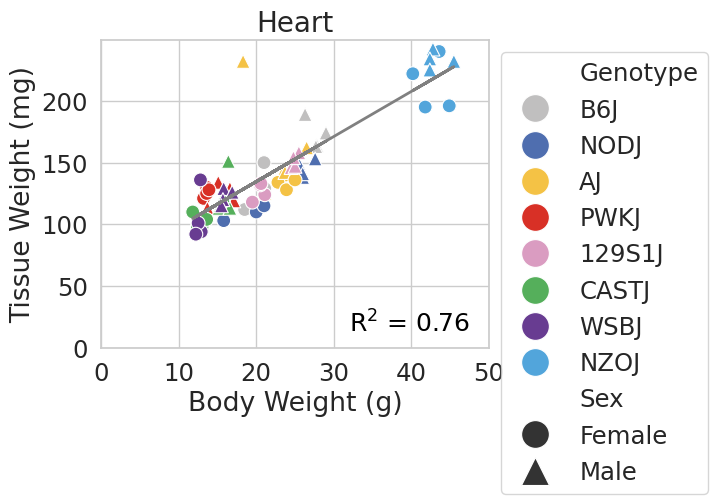

Liver


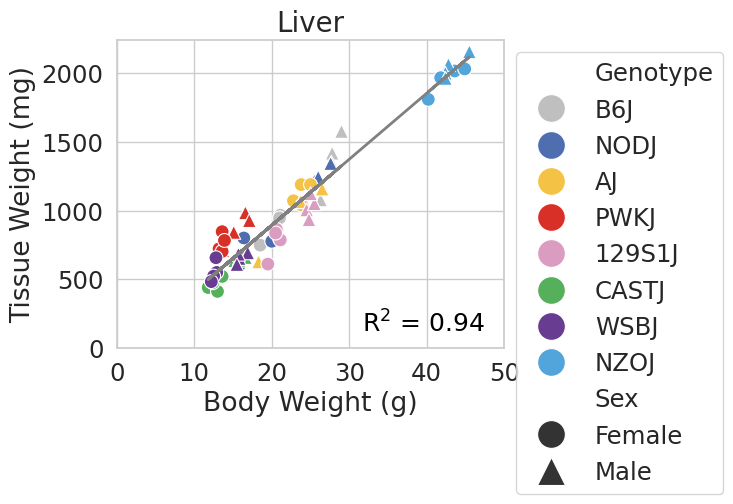

DiencephalonPituitary


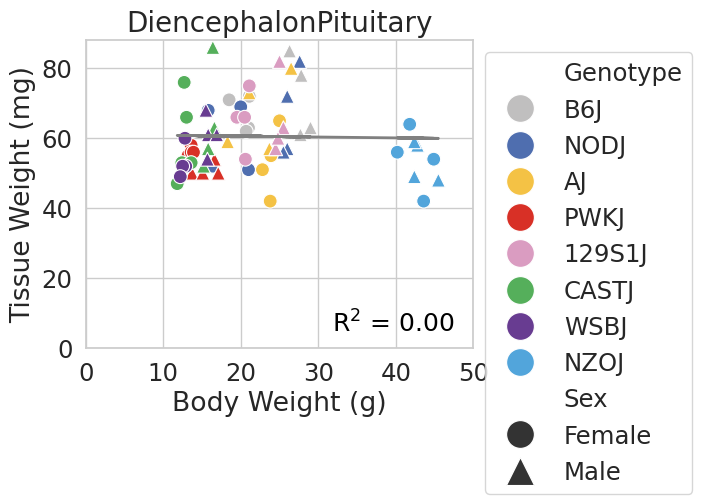

Ovary/Oviduct


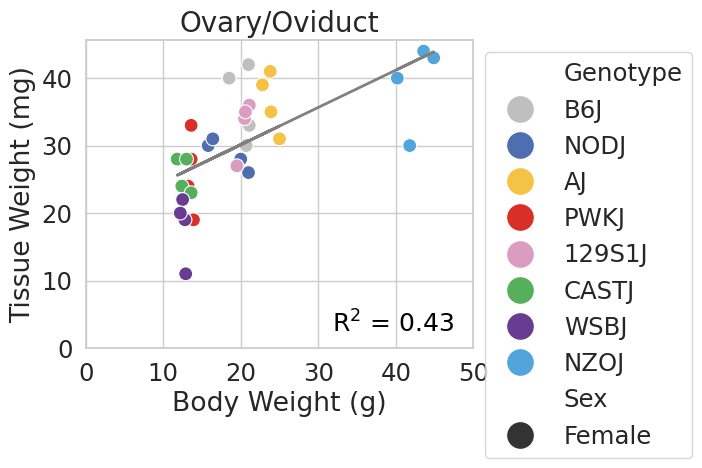

Testes/Epididymis


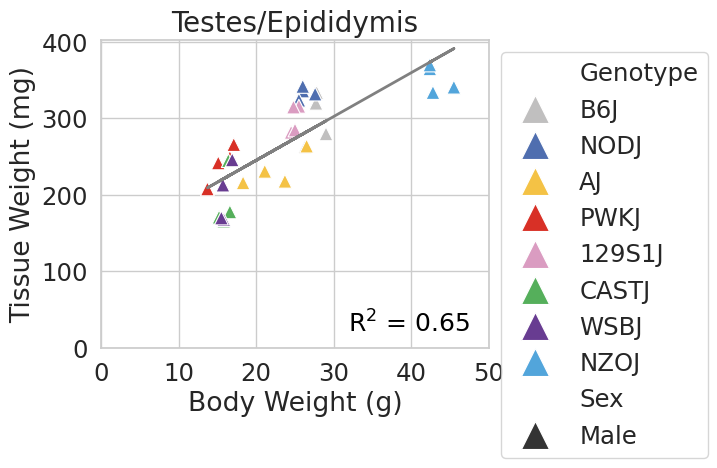

Adrenal gland


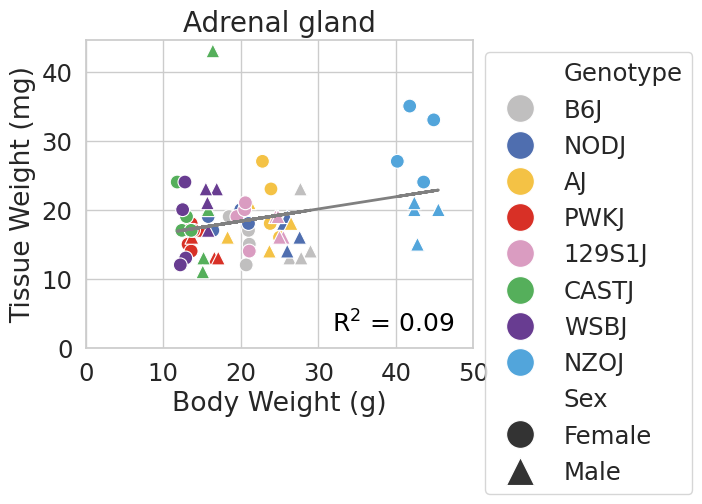

Kidney


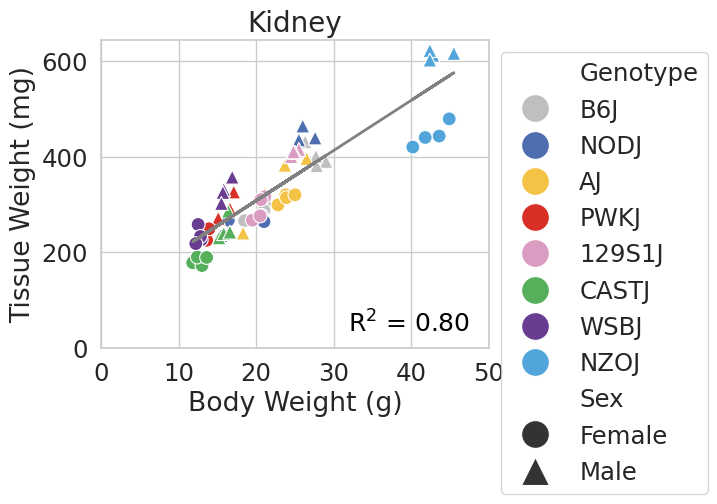

Gastrocnemius


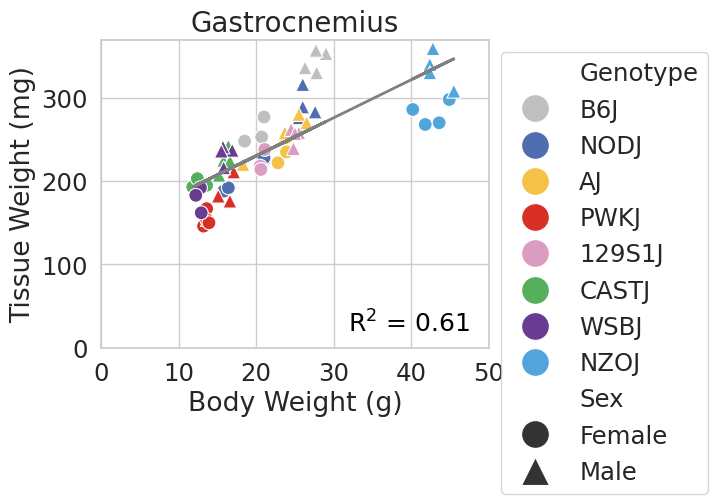

{'Cortex/Hippocampus': 0.01575297025693001, 'Heart': 0.7558675575344331, 'Liver': 0.941285388746016, 'DiencephalonPituitary': 0.0005098787807413796, 'Ovary/Oviduct': 0.4293878936013259, 'Testes/Epididymis': 0.6531458865228941, 'Adrenal gland': 0.08630925690992919, 'Kidney': 0.7997642009793446, 'Gastrocnemius': 0.6107022406871243}


In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Define genotype palette
geno_palette = {
    '129S1J': '#DA9CC1',
    'AJ': '#F4C245',
    'B6J': '#C0BFBF',
    'CASTJ': '#55AF5B',
    'NODJ': '#4F6EAF',
    'NZOJ': '#52A5DB',
    'PWKJ': '#D83026',
    'WSBJ': '#683C91'
}

# Assuming your DataFrame is named df
# Convert 'Body_weight_g' and 'Tissue_weight_mg' columns to numeric
df['Body_weight_g'] = pd.to_numeric(df['Body_weight_g'])
df['Tissue_weight_mg'] = pd.to_numeric(df['Tissue_weight_mg'])

# Drop rows with NaN values
df.dropna(subset=['Body_weight_g', 'Tissue_weight_mg'], inplace=True)

# Get unique tissue types
unique_tissues = df['Tissue'].unique()

# Set up the plot
sns.set(style="whitegrid", font_scale=1.6)

r_squared_values = {}

# Iterate over unique tissues and create scatter plots
for tissue in unique_tissues:
    plt.figure(figsize=(5, 4))
    tissue_df = df[df['Tissue'] == tissue]
    print(tissue)
    
    # Define marker styles
    marker_style = 'o' if tissue == 'Ovary/Oviduct' else '^' if tissue == 'Testes/Epididymis' else {'Male': '^', 'Female': 'o'}
    
    # Create scatter plot
    sns.scatterplot(data=tissue_df, x='Body_weight_g', y='Tissue_weight_mg', hue='Genotype', style='Sex', 
                    palette=geno_palette, markers=marker_style, s=100)
    
    # Fit linear regression model
    X = tissue_df[['Body_weight_g']]
    y = tissue_df['Tissue_weight_mg']
    model = LinearRegression()
    model.fit(X, y)
    
    # Predict values and calculate R^2
    y_pred = model.predict(X)
    r_squared = r2_score(y, y_pred)
    
    r_squared_values[tissue] = r_squared
    
    # Overlay regression line
    plt.plot(X, y_pred, color='grey', linestyle='-', linewidth=2)
    
    # Set x and y limits
    plt.xlim(0, 50)
    plt.ylim(0, None)
    
    # Add legend outside the plot
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1), markerscale=2)
    
    # Add labels and title with increased font size
    plt.xlabel('Body Weight (g)')
    plt.ylabel('Tissue Weight (mg)')
    plt.title(f'{tissue}', fontsize=20)
    
    # Annotate plot with R^2 value
    plt.text(0.95, 0.05, f'R$^2$ = {r_squared:.2f}', transform=plt.gca().transAxes, 
             ha='right', fontsize=18, color='black')
    
    # Save plot as PDF
    plt.savefig(f'../supp_fig1/{tissue.replace("/", "").replace(" ", "")}_weight_scatter.pdf', bbox_inches='tight')
    
    # Show plot
    plt.show()

# Print R^2 values for each tissue
print(r_squared_values)
